# 14 — Decision Tree Classifier (Classification Track — Part A)
**23CSE301 Machine Learning — Capstone, Review 1**

**Dataset:** Employee promotion (`train.csv`) **Target:** `is_promoted` (1 = promoted, 0 = not promoted)

| Block | Rubric section |
|---|---|
| 1 | Section A — Dataset & EDA |
| 2 | Section B — Preprocessing & Feature Engineering |
| 3 | Section D — Classification Track, Part A (Decision Tree Classifier) |

A Decision Tree Classifier splits the employees with a series of **if/else questions** (e.g. `avg_training_score > 78?`) chosen to make each group as **pure** as possible (measured by Gini impurity or entropy), and predicts the majority class of each leaf. It needs no scaling and is easy to read, but a fully grown tree **memorises the training data**, so **max_depth** and leaf size must be tuned. With only 8.5% promotions, **class_weight** matters too.

---
# BLOCK 1 — Dataset & EDA (Section A)

In [1]:
# ============================================================
# BLOCK 1 : DATASET & EDA
# ============================================================

# ---- 1.0 Imports & global settings ----
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42                      # fixed seed for reproducibility (guideline 7.1)
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")   # colour-blind-friendly palette (guideline 7.3)
pd.set_option("display.max_columns", 50)

DATA_PATH = "../data/train.csv"        # change if your file is somewhere else
TARGET = "is_promoted"

**Note on the dataset files:** the original download has `train.csv` (labelled) and `test.csv` (**no `is_promoted` column**).
Because the test file has no labels, it cannot be used to measure accuracy, so all 5 classifiers use `train.csv`
split 80:20 with stratification.

## A1 — Dataset loading & audit

In [2]:
# ---- 1.1 Load the dataset ----
df = pd.read_csv(DATA_PATH)

# employee_id is a unique identifier, not a predictive feature -> drop it
df = df.drop(columns=["employee_id"], errors="ignore")

# strip stray spaces from text columns
for col in df.select_dtypes(include=["object", "string"]).columns:
    df[col] = df[col].astype("object").where(df[col].isna(), df[col].astype(str).str.strip())

print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (54808, 12)


,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [3]:
# ---- 1.2 Data types, missing values & duplicates ----
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print("Duplicate rows:", df.duplicated().sum())
audit

Duplicate rows: 219


,dtype,missing_count,missing_%,n_unique
department,object,0,0.00,9
region,object,0,0.00,34
education,object,2409,4.40,3
gender,object,0,0.00,2
recruitment_channel,object,0,0.00,3
no_of_trainings,int64,0,0.00,10
age,int64,0,0.00,41
previous_year_rating,float64,4124,7.52,5
length_of_service,int64,0,0.00,35
awards_won?,int64,0,0.00,2


In [4]:
# ---- 1.3 Statistical summary of numeric columns ----
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_trainings,54808.0,1.253011,0.609264,1.0,1.0,1.0,1.0,10.0
age,54808.0,34.803915,7.660169,20.0,29.0,33.0,39.0,60.0
previous_year_rating,50684.0,3.329256,1.259993,1.0,3.0,3.0,4.0,5.0
length_of_service,54808.0,5.865512,4.265094,1.0,3.0,5.0,7.0,37.0
awards_won?,54808.0,0.023172,0.150450,0.0,0.0,0.0,0.0,1.0
avg_training_score,54808.0,63.386750,13.371559,39.0,51.0,60.0,76.0,99.0
is_promoted,54808.0,0.085170,0.279137,0.0,0.0,0.0,0.0,1.0


is_promoted
0    50140
1     4668
Name: count, dtype: int64

Class balance (%):
is_promoted
0    91.48
1     8.52
Name: proportion, dtype: float64

Imbalance ratio  ->  1 promoted for every 10.7 not promoted


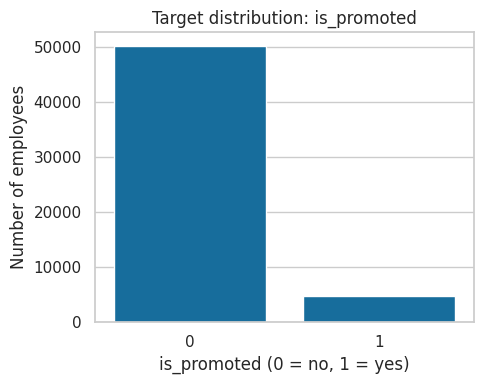

In [5]:
# ---- 1.4 Class distribution of the target (class imbalance check) ----
counts = df[TARGET].value_counts().sort_index()
print(counts)
print("\nClass balance (%):")
print((df[TARGET].value_counts(normalize=True) * 100).round(2))
print("\nImbalance ratio  ->  1 promoted for every %.1f not promoted" % (counts[0] / counts[1]))

plt.figure(figsize=(5, 4))
sns.countplot(x=df[TARGET])
plt.title("Target distribution: is_promoted")
plt.xlabel("is_promoted (0 = no, 1 = yes)"); plt.ylabel("Number of employees")
plt.tight_layout(); plt.show()

**📝 What this shows:** Only 8.5% of employees were promoted, so a model that says 'nobody is promoted' would already be 91.5% accurate.

## A2 — EDA visualisations

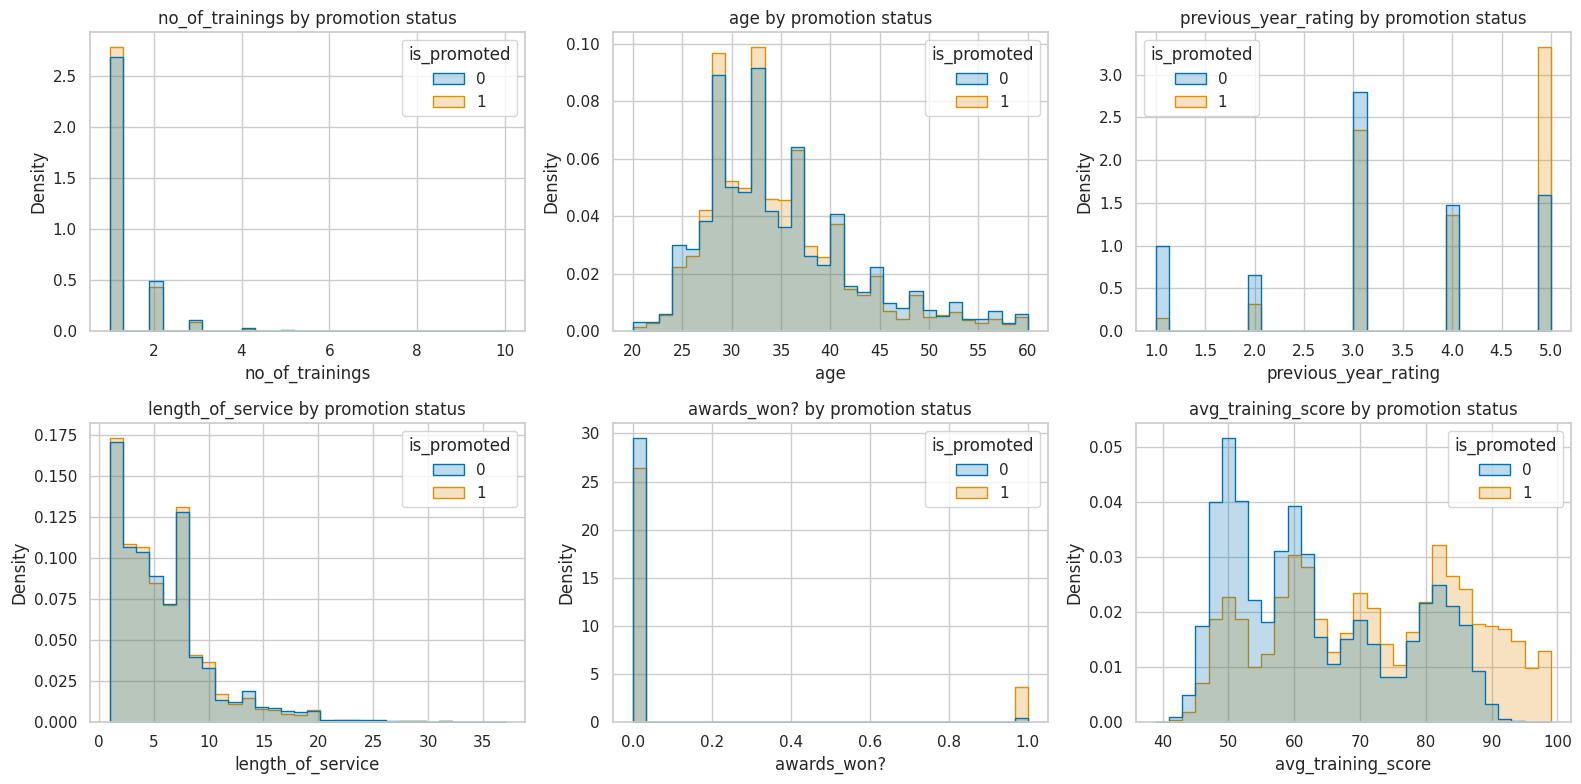

In [6]:
# ---- 1.5 Distribution of EACH numeric feature, split by class ----
num_features = ["no_of_trainings", "age", "previous_year_rating", "length_of_service",
                "awards_won?", "avg_training_score"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_features):
    sns.histplot(data=df, x=col, hue=TARGET, bins=30, element="step", stat="density",
                 common_norm=False, ax=ax)
    ax.set_title(f"{col} by promotion status")
    ax.set_xlabel(col); ax.set_ylabel("Density")
plt.tight_layout(); plt.show()

**📝 What this shows:** Promoted employees have a much higher training score (71 vs 63) and far more awards; age and service length look the same for both groups.

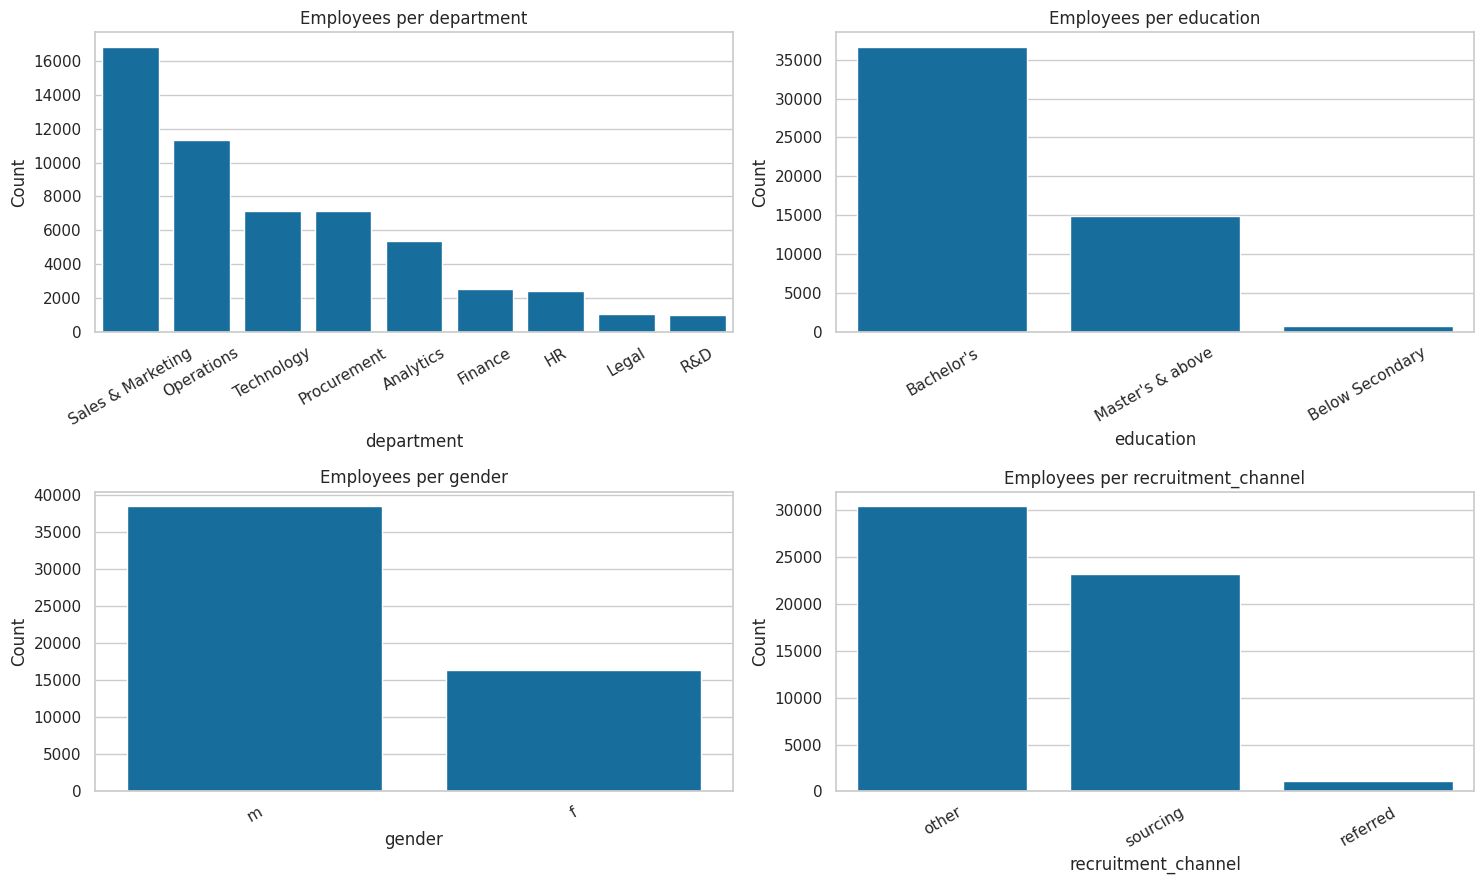

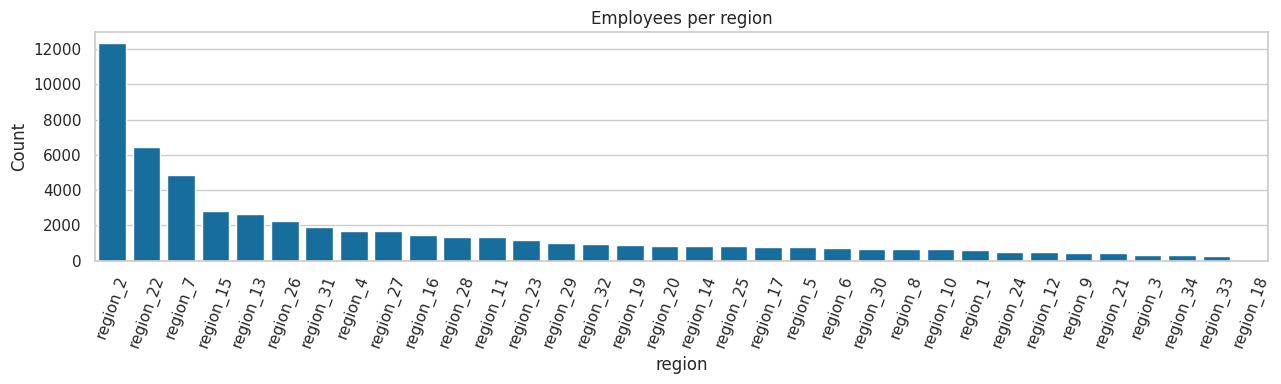

In [7]:
# ---- 1.6 Distribution of EACH categorical feature ----
cat_features = ["department", "region", "education", "gender", "recruitment_channel"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax)
    ax.set_title(f"Employees per {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

plt.figure(figsize=(13, 4))
sns.countplot(data=df, x="region", order=df["region"].value_counts().index)
plt.title("Employees per region"); plt.xlabel("region"); plt.ylabel("Count"); plt.xticks(rotation=70)
plt.tight_layout(); plt.show()

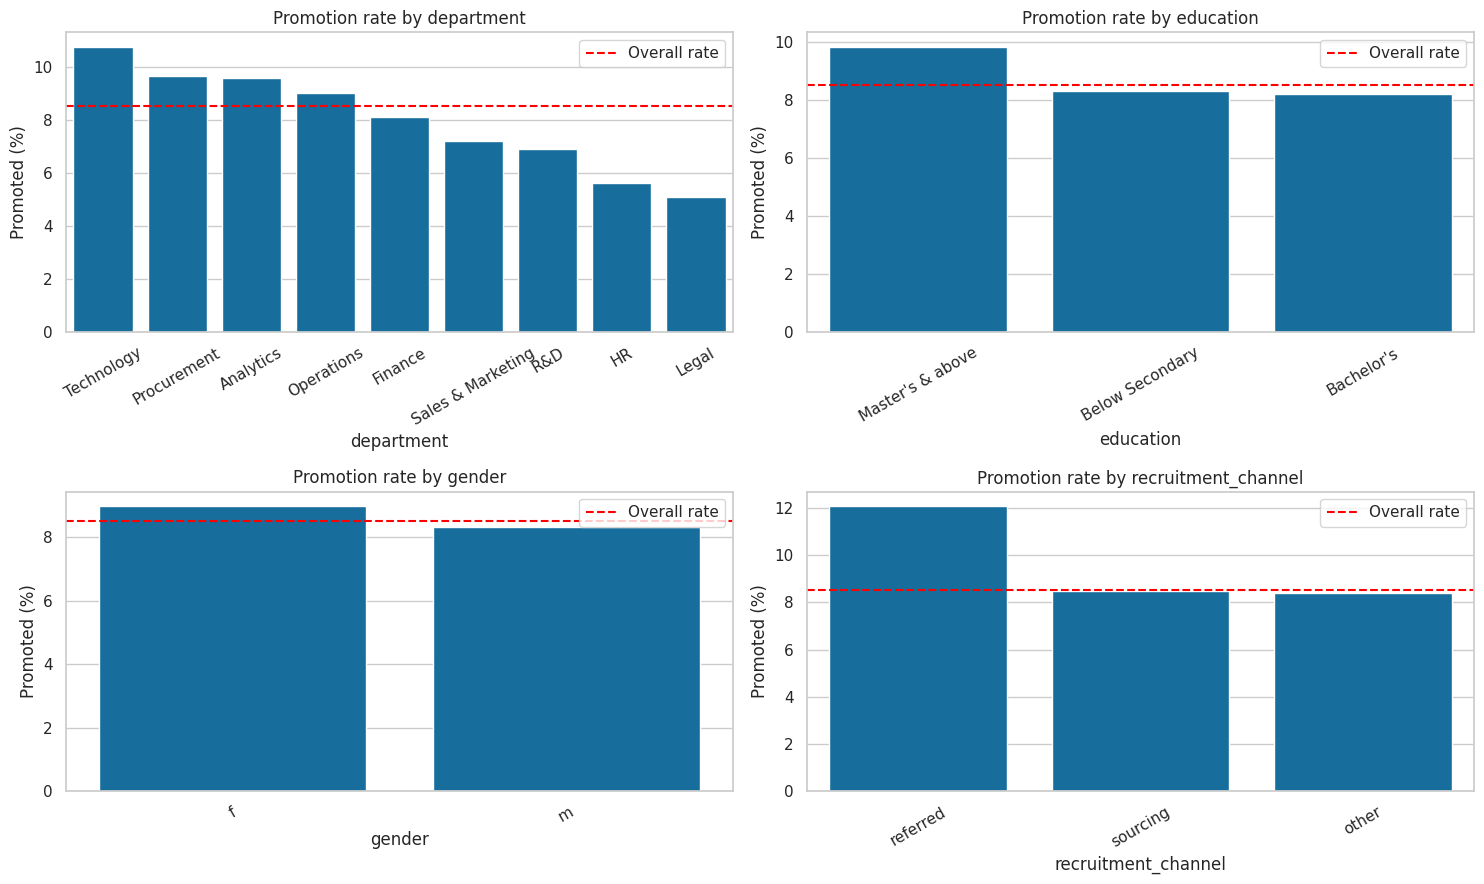

In [8]:
# ---- 1.7 Promotion RATE per category (the class distribution within each group) ----
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, col in zip(axes.flat, ["department", "education", "gender", "recruitment_channel"]):
    rate = df.groupby(col, dropna=False)[TARGET].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.axhline(df[TARGET].mean() * 100, color="red", linestyle="--", label="Overall rate")
    ax.set_title(f"Promotion rate by {col}")
    ax.set_xlabel(col); ax.set_ylabel("Promoted (%)"); ax.tick_params(axis="x", rotation=30); ax.legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** Technology promotes the most (10.8%) and Legal the least (5.1%), and referred employees do best at 12.1%.

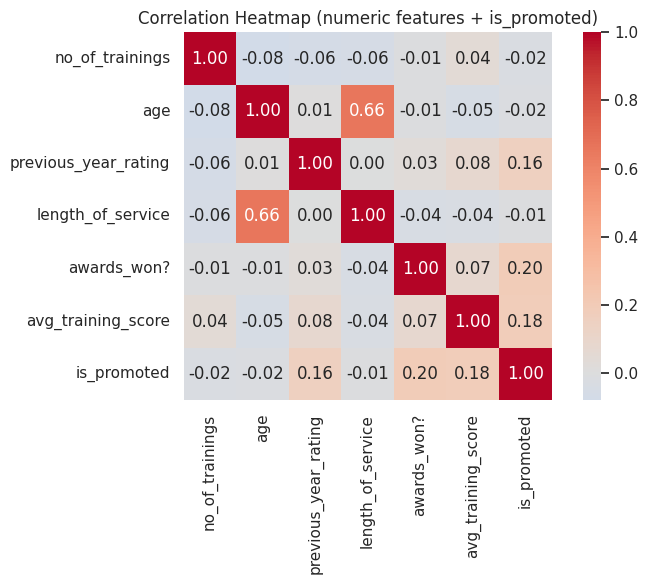

In [9]:
# ---- 1.8 Correlation heatmap (numeric features + target) ----
plt.figure(figsize=(8, 6))
corr = df[num_features + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features + is_promoted)")
plt.tight_layout(); plt.show()

**📝 What this shows:** Awards (0.196) and training score (0.181) link most to promotion, but all links are weak; age and service length are strongly tied to each other (0.66).

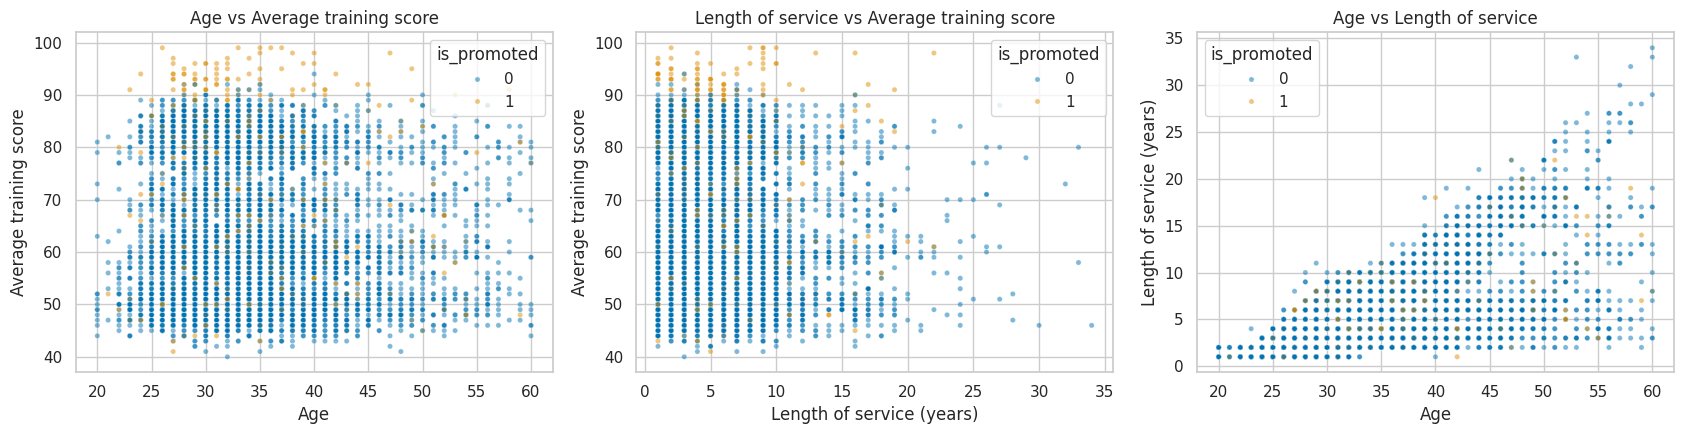

In [10]:
# ---- 1.9 Scatter plots: feature relationships coloured by the target ----
sample = df.sample(6000, random_state=RANDOM_STATE)     # sample so the plots stay readable

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.scatterplot(data=sample, x="age", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[0])
axes[0].set_title("Age vs Average training score")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="length_of_service", y="avg_training_score", hue=TARGET, alpha=0.5, s=14, ax=axes[1])
axes[1].set_title("Length of service vs Average training score")
axes[1].set_xlabel("Length of service (years)"); axes[1].set_ylabel("Average training score")

sns.scatterplot(data=sample, x="age", y="length_of_service", hue=TARGET, alpha=0.5, s=14, ax=axes[2])
axes[2].set_title("Age vs Length of service")
axes[2].set_xlabel("Age"); axes[2].set_ylabel("Length of service (years)")
plt.tight_layout(); plt.show()

**📝 What this shows:** The two groups overlap almost completely, and only training score separates them, with promoted people sitting near the top.

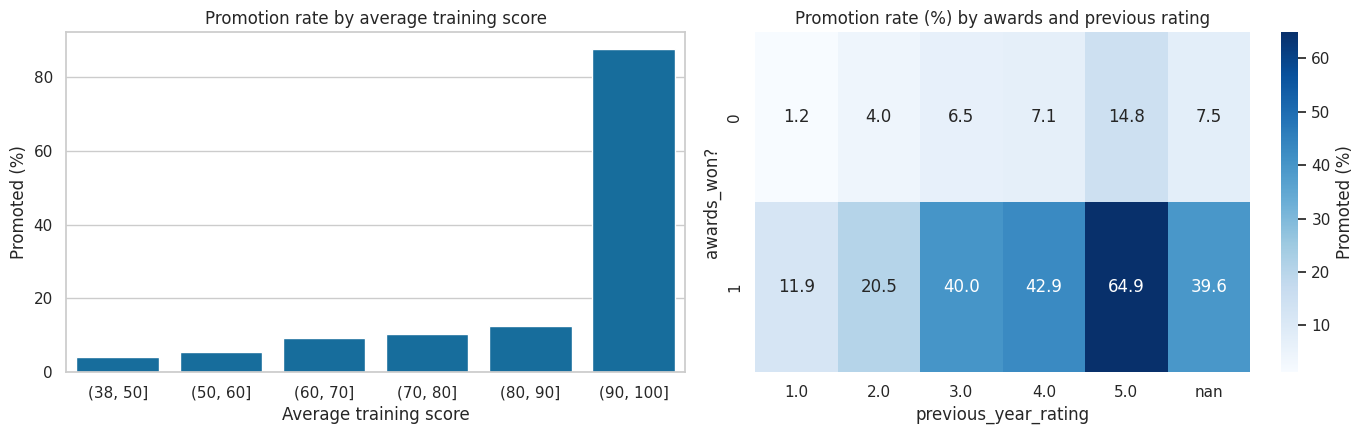

In [11]:
# ---- 1.10 Promotion rate by training score and by awards ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
score_bins = pd.cut(df["avg_training_score"], bins=[38, 50, 60, 70, 80, 90, 100])
rate = df.groupby(score_bins, observed=True)[TARGET].mean() * 100
sns.barplot(x=rate.index.astype(str), y=rate.values, ax=axes[0])
axes[0].set_title("Promotion rate by average training score")
axes[0].set_xlabel("Average training score"); axes[0].set_ylabel("Promoted (%)")

rate2 = df.groupby(["awards_won?", "previous_year_rating"], dropna=False)[TARGET].mean().unstack() * 100
sns.heatmap(rate2, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={"label": "Promoted (%)"})
axes[1].set_title("Promotion rate (%) by awards and previous rating")
axes[1].set_xlabel("previous_year_rating"); axes[1].set_ylabel("awards_won?")
plt.tight_layout(); plt.show()

**📝 What this shows:** Scoring above 90 gives an 87.7% promotion rate, and an award plus a rating of 5 gives 64.9%.

---
# BLOCK 2 — Preprocessing & Feature Engineering (Section B)

In [12]:
# ============================================================
# BLOCK 2 : PREPROCESSING & FEATURE ENGINEERING
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# ---- 2.1 Remove duplicate rows ----
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {before - len(df)}  ->  rows now: {len(df)}")

# ---- 2.2 Understand the missing values before deciding a strategy ----
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# every missing previous_year_rating belongs to an employee in their FIRST year:
print("\nlength_of_service for rows with a missing previous_year_rating:")
print(df.loc[df["previous_year_rating"].isnull(), "length_of_service"].value_counts().head())

# is the missing education informative? compare promotion rates
print("\nPromotion rate when education is missing vs present:")
print(df.groupby(df["education"].isnull())[TARGET].mean().round(4))

Duplicates removed: 219  ->  rows now: 54589

Missing values:
education               2391
previous_year_rating    4013
dtype: int64

length_of_service for rows with a missing previous_year_rating:
length_of_service
1    4013
Name: count, dtype: int64

Promotion rate when education is missing vs present:
education
False    0.087
True     0.051
Name: is_promoted, dtype: float64


**Missing-value strategy (justified):**

| Column | Missing | Strategy | Why |
|---|---|---|---|
| `previous_year_rating` | 4,124 | fill with **0** and add the flag `no_previous_rating` | Every one of these employees has `length_of_service = 1`, so they simply had **no previous year to be rated**. 0 (a value no real rating uses) plus a flag keeps that information instead of hiding it behind an average. |
| `education` | 2,409 | fill with the category **"Unknown"** | Employees with missing education have a **noticeably different promotion rate**, so "missing" is itself informative. Replacing it with the most common value would destroy that signal. |

In [13]:
# ---- 2.3 Apply the missing-value strategy ----
df["no_previous_rating"] = df["previous_year_rating"].isnull().astype(int)   # flag column
df["previous_year_rating"] = df["previous_year_rating"].fillna(0)
df["education"] = df["education"].fillna("Unknown")

print("Missing values now:", int(df.isnull().sum().sum()))

Missing values now: 0


## B3 — Feature engineering

In [14]:
# ---- 2.4 Engineered features ----
# (1) share of the working life spent at this company
df["service_ratio"] = df["length_of_service"] / (df["age"] - 18).clip(lower=1)

# (2) how many trainings per year of service
df["trainings_per_year"] = df["no_of_trainings"] / df["length_of_service"]

# (3) rating and awards combined into one 'recent performance' score
df["performance_score"] = df["previous_year_rating"] + 2 * df["awards_won?"]

engineered = ["service_ratio", "trainings_per_year", "performance_score"]
df.groupby(TARGET)[engineered].mean().round(3)

,service_ratio,trainings_per_year,performance_score
is_promoted,,,
0,0.344,0.372,3.056
1,0.344,0.357,3.938


**Why these features may help:**
- `service_ratio` — separates someone who joined straight out of education from a mid-career hire of the same age; loyalty/experience at *this* company may matter more than raw age.
- `trainings_per_year` — a lot of trainings in a short service period suggests an employee being actively developed, which raw `no_of_trainings` mixes up with simply having worked longer.
- `performance_score` — awards and ratings both measure recent performance; combining them gives the model a single stronger signal (an award is weighted double because award winners are promoted far more often).

*(A 4th feature, `score_vs_dept_avg`, is built after the split in cell 2.7 because it needs statistics from the training set only.)*

## B2 — Stratified train/test split, encoding & scaling

In [15]:
# ---- 2.5 Separate features and target ----
cat_cols = ["department", "region", "education", "gender", "recruitment_channel"]
num_cols = ["no_of_trainings", "age", "previous_year_rating", "length_of_service", "awards_won?",
            "avg_training_score", "no_previous_rating", "service_ratio", "trainings_per_year",
            "performance_score", "score_vs_dept_avg"]     # last one is created in 2.7

X = df[cat_cols + [c for c in num_cols if c != "score_vs_dept_avg"]]
y = df[TARGET]

# ---- 2.6 Stratified 80:20 split ----
# stratify=y keeps the same 8.5% promotion rate in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Promotion rate  train: %.4f | test: %.4f" % (y_train.mean(), y_test.mean()))

Train: (43671, 15)  Test: (10918, 15)
Promotion rate  train: 0.0855 | test: 0.0855


In [16]:
# ---- 2.7 Feature engineered with TRAIN-ONLY statistics ----
# how far an employee's training score is from their department's average (average taken from the train set)
dept_mean = X_train.groupby("department")["avg_training_score"].mean()
overall_mean = X_train["avg_training_score"].mean()

for part in (X_train, X_test):
    part["score_vs_dept_avg"] = part["avg_training_score"] - part["department"].map(dept_mean).fillna(overall_mean)

print(X_train[["avg_training_score", "score_vs_dept_avg"]].describe().T.round(2))

                      count   mean    std    min    25%    50%    75%    max
avg_training_score  43671.0  63.41  13.38  39.00  51.00  60.00  76.00  99.00
score_vs_dept_avg   43671.0  -0.00   4.61 -11.96  -2.27  -0.27   1.73  48.73


In [17]:
# ---- 2.8 Outlier check (IQR) & treatment (capping) ----
outlier_report, caps = {}, {}
for col in ["no_of_trainings", "age", "length_of_service", "service_ratio", "trainings_per_year"]:
    q1, q3 = X_train[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_report[col] = int(((X_train[col] < low) | (X_train[col] > high)).sum())
    caps[col] = (X_train[col].quantile(0.01), X_train[col].quantile(0.99))   # train-derived limits

print("IQR outliers in train set:")
print(pd.Series(outlier_report))

for col, (lo, hi) in caps.items():
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)     # the same train limits are applied to test

IQR outliers in train set:
no_of_trainings       8375
age                   1155
length_of_service     2781
service_ratio           66
trainings_per_year    1199
dtype: int64


**Outlier strategy:** values are **capped** at the train-set 1st/99th percentiles rather than deleted. Extreme cases
(e.g. 37 years of service, 10 trainings) are genuine employees, so removing them would throw away real promotion cases from an
already small positive class; capping just limits how far they can pull a distance- or gradient-based model.

In [18]:
# ---- 2.9 Encoding + scaling (fitted on TRAIN only -> no data leakage) ----
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),                                              # scale numeric features
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),   # one-hot encode categoricals
])

X_train_p = preprocessor.fit_transform(X_train)    # FIT + transform on train
X_test_p = preprocessor.transform(X_test)          # ONLY transform on test

feature_names = preprocessor.get_feature_names_out()
print("Processed train shape:", X_train_p.shape)
print("Processed test shape :", X_test_p.shape)
print("Positive class in train: %d (%.2f%%)" % (y_train.sum(), 100 * y_train.mean()))

Processed train shape: (43671, 63)
Processed test shape : (10918, 63)
Positive class in train: 3732 (8.55%)


**Handling the class imbalance:** only ~8.5% of employees were promoted. Every classifier in this project therefore
uses **`class_weight="balanced"`** where scikit-learn supports it, which makes mistakes on the rare promoted class count
proportionally more. Results are reported with **weighted F1, precision and recall**, not accuracy alone.

---
# BLOCK 3 — Classification Track Part A: Decision Tree Classifier (Section D)

*Note:* trees do not need feature scaling (a split on `age <= 35` works the same on scaled values). We still use the same processed
data as the other four classifiers, so all of Part A is compared on **exactly the same inputs and test split**.

In [19]:
# ============================================================
# BLOCK 3 : CLASSIFICATION — DECISION TREE CLASSIFIER
# ============================================================
import time
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.model_selection import GridSearchCV, cross_val_score, StratifiedKFold, validation_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # keeps the 8.5% rate in every fold

def classification_metrics(y_true, y_hat, scores=None):
    # accuracy + weighted metrics (rubric D2) + metrics for the rare 'promoted' class
    out = {
        "Accuracy": accuracy_score(y_true, y_hat),
        "F1_weighted": f1_score(y_true, y_hat, average="weighted"),
        "Precision_weighted": precision_score(y_true, y_hat, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_hat, average="weighted"),
        "F1_promoted": f1_score(y_true, y_hat, pos_label=1, zero_division=0),
        "Recall_promoted": recall_score(y_true, y_hat, pos_label=1),
    }
    if scores is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, scores)
    return out

# ---- 3.1 Train a default (fully grown) Decision Tree ----
start = time.time()
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train_p, y_train)
print(f"Training time: {time.time() - start:.2f} s")
print("Depth:", dt_default.get_depth(), "| leaves:", dt_default.get_n_leaves())

# ---- 3.2 Predictions ----
y_pred_default = dt_default.predict(X_test_p)
y_proba_default = dt_default.predict_proba(X_test_p)[:, 1]
print("Predicted promotions:", int(y_pred_default.sum()), "| actual promotions:", int(y_test.sum()))

default_scores = classification_metrics(y_test, y_pred_default, y_proba_default)
print("Train accuracy: %.4f  <- a fully grown tree memorises the training data"
      % accuracy_score(y_train, dt_default.predict(X_train_p)))
pd.DataFrame([default_scores], index=["Decision Tree (default, unlimited depth)"]).round(4)

Training time: 0.39 s
Depth: 43 | leaves: 4488
Predicted promotions: 1108 | actual promotions: 933
Train accuracy: 0.9997  <- a fully grown tree memorises the training data


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
"Decision Tree (default, unlimited depth)",0.8863,0.8907,0.8957,0.8863,0.392,0.4287,0.6788


**📝 What this shows:** The tree got 99.97% on training data but only 88.6% on test data, which is worse than saying 'nobody is promoted'.

## Tuning max_depth

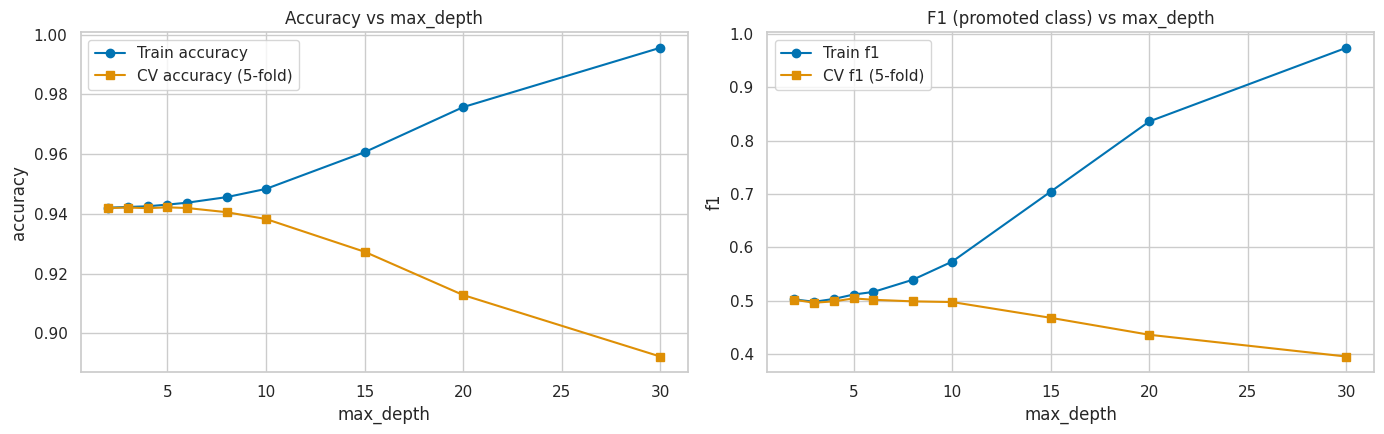

In [20]:
# ---- 3.3 Effect of max_depth: validation curves for accuracy and F1 ----
depths = [2, 3, 4, 5, 6, 8, 10, 15, 20, 30]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, metric in zip(axes, ["accuracy", "f1"]):
    train_sc, val_sc = validation_curve(
        DecisionTreeClassifier(random_state=RANDOM_STATE), X_train_p, y_train,
        param_name="max_depth", param_range=depths, cv=skf, scoring=metric, n_jobs=-1
    )
    ax.plot(depths, train_sc.mean(axis=1), "o-", label=f"Train {metric}")
    ax.plot(depths, val_sc.mean(axis=1), "s-", label=f"CV {metric} (5-fold)")
    ax.set_title(f"{'Accuracy' if metric == 'accuracy' else 'F1 (promoted class)'} vs max_depth")
    ax.set_xlabel("max_depth"); ax.set_ylabel(metric)
    ax.legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** Accuracy hides the problem because 91.5% of employees were not promoted, while F1 shows a clear best depth.

## Hyperparameter tuning (GridSearchCV)
The scoring metric is **F1 of the promoted class**, not accuracy: with 91.5% negatives, accuracy would reward a tree that
predicts "not promoted" for everyone. `class_weight` is tuned as well, because it is the tree's main lever for the imbalance.

In [21]:
# ---- 3.4 GridSearchCV over depth, leaf size, split criterion and class weighting ----
param_grid = {
    "max_depth": [4, 6, 8, 10, 15, None],
    "min_samples_leaf": [1, 10, 50, 100],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}
grid = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE), param_grid,
                    cv=skf, scoring="f1", n_jobs=-1, return_train_score=True)
start = time.time()
grid.fit(X_train_p, y_train)
print(f"Search time: {time.time() - start:.1f} s  ({len(pd.DataFrame(grid.cv_results_))} combinations × 5 folds)")

best_params = grid.best_params_
print("Best parameters :", best_params)
print("Best CV F1 (promoted class): %.4f" % grid.best_score_)

cv_res = pd.DataFrame(grid.cv_results_)
# pandas stores a None hyper-parameter as NaN, so fill it back in before comparing
cv_res["param_max_depth"] = cv_res["param_max_depth"].astype(object).fillna("None").astype(str)
cv_res["param_class_weight"] = cv_res["param_class_weight"].astype(object).fillna("None").astype(str)
cv_res[["param_max_depth", "param_min_samples_leaf", "param_criterion", "param_class_weight",
        "mean_train_score", "mean_test_score"]].sort_values("mean_test_score", ascending=False).head(10).round(4)

Search time: 79.6 s  (96 combinations × 5 folds)
Best parameters : {'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 50}
Best CV F1 (promoted class): 0.5032


,param_max_depth,param_min_samples_leaf,param_criterion,param_class_weight,mean_train_score,mean_test_score
6,6,50,gini,None,0.5067,0.5032
10,8,50,gini,None,0.5067,0.5032
14,10,50,gini,None,0.5067,0.5032
18,15,50,gini,None,0.5067,0.5032
22,None,50,gini,None,0.5067,0.5032
46,None,50,entropy,None,0.5074,0.5031
42,15,50,entropy,None,0.5074,0.5031
34,8,50,entropy,None,0.5074,0.5031
38,10,50,entropy,None,0.5074,0.5030
9,8,10,gini,None,0.5214,0.5026


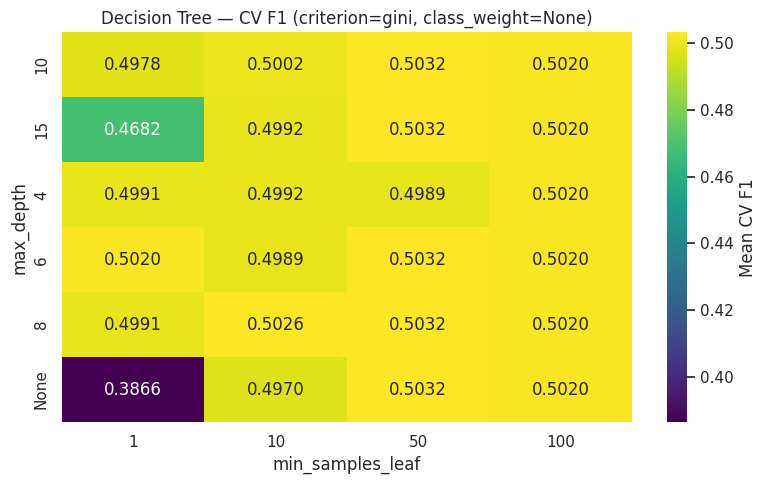

In [22]:
# ---- 3.5 Heatmap of CV F1 (depth × leaf size) for the winning criterion/class_weight ----
mask = (cv_res["param_criterion"] == best_params["criterion"]) & \
       (cv_res["param_class_weight"] == str(best_params["class_weight"]))
heat = cv_res[mask].pivot_table(index="param_max_depth", columns="param_min_samples_leaf", values="mean_test_score")
plt.figure(figsize=(8, 5))
sns.heatmap(heat, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "Mean CV F1"})
plt.title(f"Decision Tree — CV F1 (criterion={best_params['criterion']}, class_weight={best_params['class_weight']})")
plt.xlabel("min_samples_leaf"); plt.ylabel("max_depth")
plt.tight_layout(); plt.show()

**📝 What this shows:** A small tree wins (depth 6, 34 leaves), which means the real promotion rule is simple.

In [23]:
# ---- 3.6 Evaluate the tuned tree & report improvement ----
dt_best = grid.best_estimator_
y_pred = dt_best.predict(X_test_p)
y_proba = dt_best.predict_proba(X_test_p)[:, 1]
tuned_scores = classification_metrics(y_test, y_pred, y_proba)

print("Tuned tree -> depth:", dt_best.get_depth(), "| leaves:", dt_best.get_n_leaves())
print("Train accuracy: %.4f | Test accuracy: %.4f"
      % (accuracy_score(y_train, dt_best.predict(X_train_p)), tuned_scores["Accuracy"]))

compare = pd.DataFrame([default_scores, tuned_scores],
                       index=["Decision Tree default", f"Decision Tree tuned (depth={dt_best.get_depth()})"])
compare.loc["Improvement"] = compare.iloc[1] - compare.iloc[0]
compare.round(4)

Tuned tree -> depth: 6 | leaves: 34
Train accuracy: 0.9426 | Test accuracy: 0.9428


,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC
Decision Tree default,0.8863,0.8907,0.8957,0.8863,0.3920,0.4287,0.6788
Decision Tree tuned (depth=6),0.9428,0.9307,0.9423,0.9428,0.5144,0.3548,0.7920
Improvement,0.0564,0.0400,0.0466,0.0564,0.1224,-0.0740,0.1132


## Visualising the tree

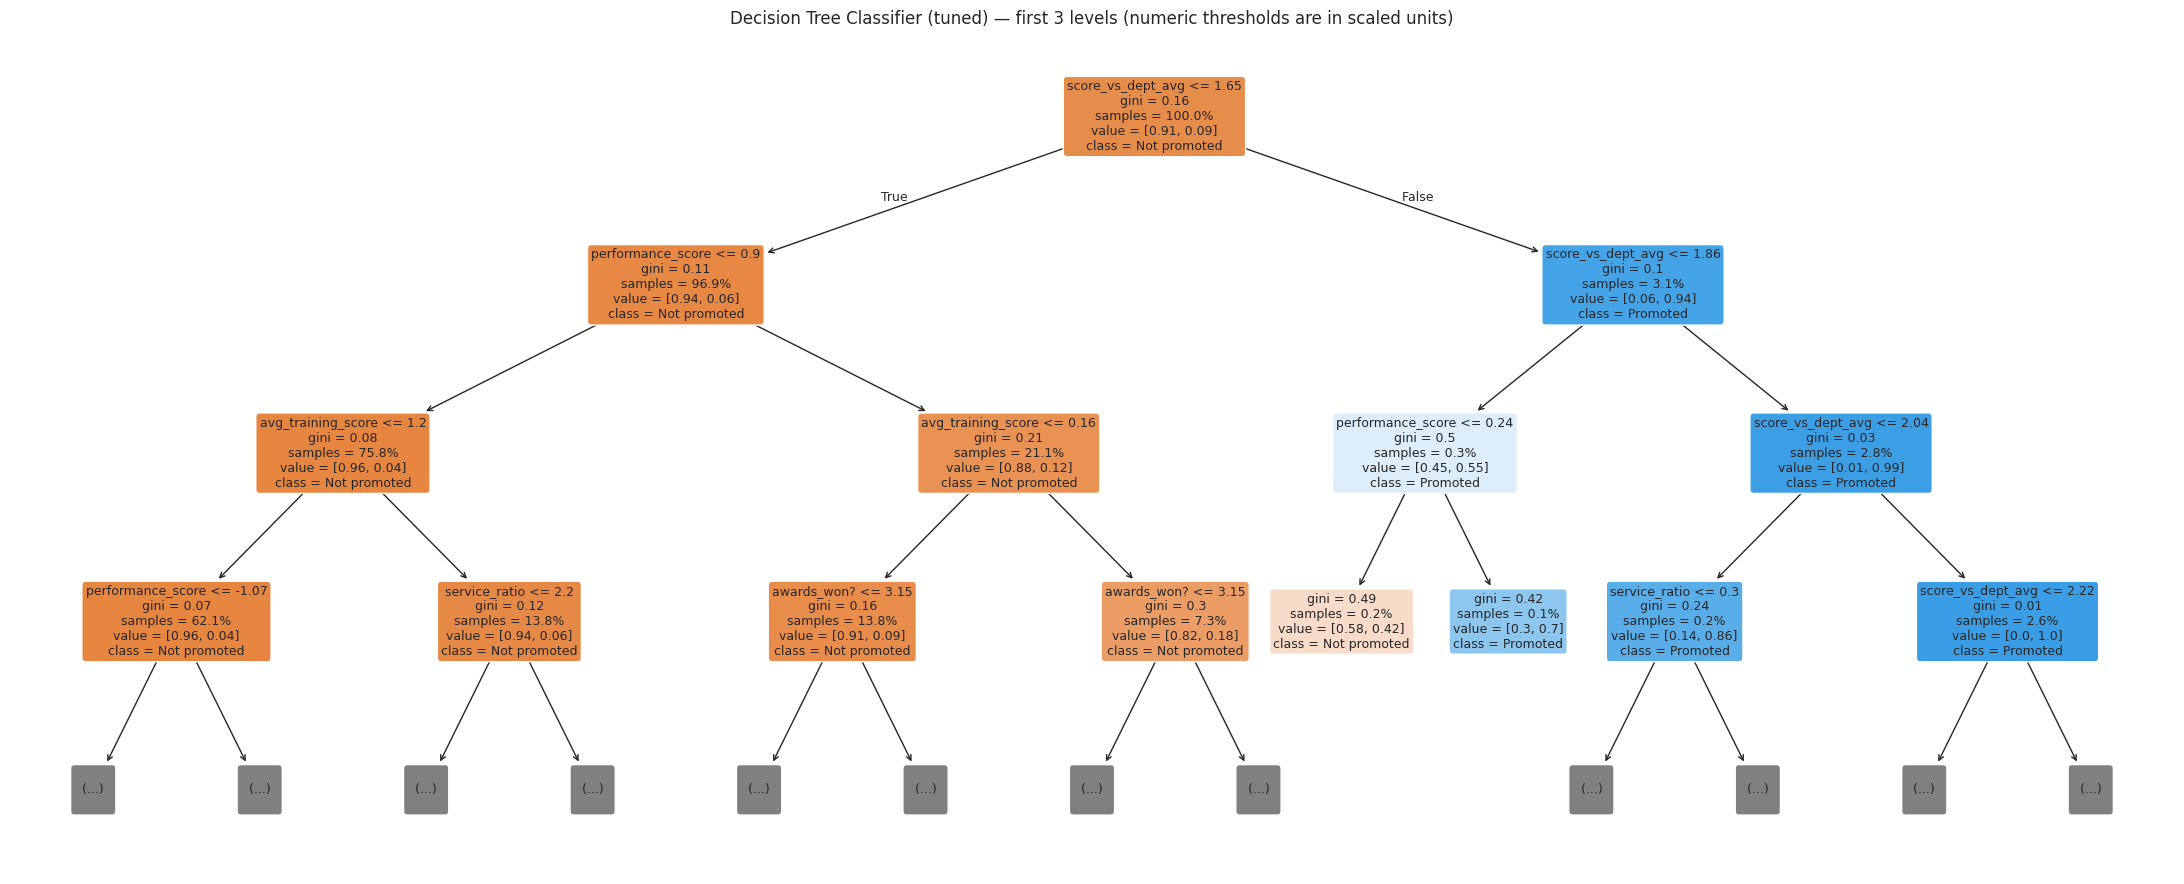

In [24]:
# ---- 3.7 Plot the top of the tuned tree ----
short_names = [f.split("__", 1)[1] for f in feature_names]
plt.figure(figsize=(22, 9))
plot_tree(dt_best, max_depth=3, feature_names=short_names, class_names=["Not promoted", "Promoted"],
          filled=True, rounded=True, proportion=True, precision=2, fontsize=9)
plt.title("Decision Tree Classifier (tuned) — first 3 levels (numeric thresholds are in scaled units)")
plt.tight_layout(); plt.show()

In [25]:
# ---- 3.8 The same rules as text ----
print(export_text(dt_best, feature_names=list(short_names), max_depth=2, show_weights=True))

|--- score_vs_dept_avg <= 1.65
|   |--- performance_score <= 0.90
|   |   |--- avg_training_score <= 1.20
|   |   |   |--- truncated branch of depth 4
|   |   |--- avg_training_score >  1.20
|   |   |   |--- truncated branch of depth 4
|   |--- performance_score >  0.90
|   |   |--- avg_training_score <= 0.16
|   |   |   |--- truncated branch of depth 4
|   |   |--- avg_training_score >  0.16
|   |   |   |--- truncated branch of depth 4
|--- score_vs_dept_avg >  1.65
|   |--- score_vs_dept_avg <= 1.86
|   |   |--- performance_score <= 0.24
|   |   |   |--- weights: [40.00, 29.00] class: 0
|   |   |--- performance_score >  0.24
|   |   |   |--- weights: [17.00, 40.00] class: 1
|   |--- score_vs_dept_avg >  1.86
|   |   |--- score_vs_dept_avg <= 2.04
|   |   |   |--- truncated branch of depth 2
|   |   |--- score_vs_dept_avg >  2.04
|   |   |   |--- truncated branch of depth 3



**📝 What this shows:** The first question is whether the employee scores about 7.6 points above their department's average.

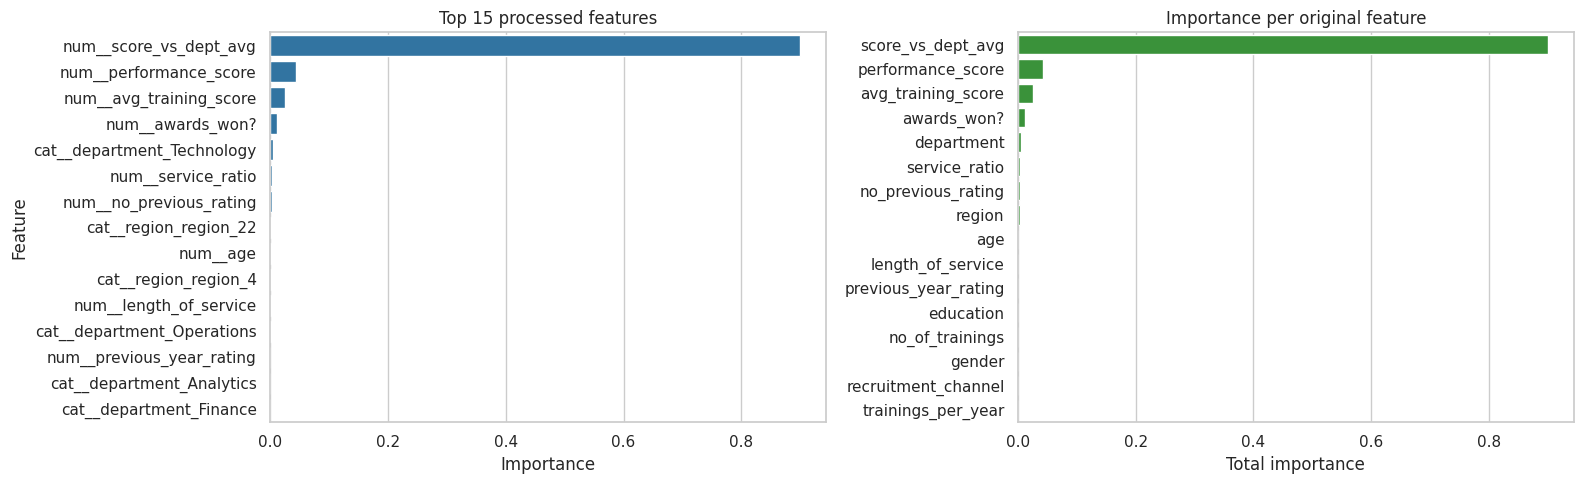

original
score_vs_dept_avg       0.8990
performance_score       0.0436
avg_training_score      0.0259
awards_won?             0.0122
department              0.0063
service_ratio           0.0038
no_previous_rating      0.0036
region                  0.0031
age                     0.0012
length_of_service       0.0011
previous_year_rating    0.0003
education               0.0000
no_of_trainings         0.0000
gender                  0.0000
recruitment_channel     0.0000
trainings_per_year      0.0000
Name: importance, dtype: float64

In [26]:
# ---- 3.9 Feature importance ----
def original_column(name):
    name = name.split("__", 1)[1]                     # remove 'num__' / 'cat__'
    for c in cat_cols:
        if name.startswith(c + "_"):
            return c
    return name

imp = pd.DataFrame({"feature": feature_names, "importance": dt_best.feature_importances_})
imp["original"] = imp["feature"].apply(original_column)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top = imp.sort_values("importance", ascending=False).head(15)
sns.barplot(data=top, y="feature", x="importance", color="tab:blue", ax=axes[0])
axes[0].set_title("Top 15 processed features"); axes[0].set_xlabel("Importance"); axes[0].set_ylabel("Feature")

grouped = imp.groupby("original")["importance"].sum().sort_values(ascending=False)
sns.barplot(x=grouped.values, y=grouped.index, color="tab:green", ax=axes[1])
axes[1].set_title("Importance per original feature"); axes[1].set_xlabel("Total importance"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()
grouped.round(4)

**📝 What this shows:** One feature we created, score_vs_dept_avg, explains 90% of the decision, and two more of our features come next.

## D2 — Evaluation: accuracy, weighted F1 and confusion matrix

In [27]:
# ---- 3.10 Full classification report ----
print(classification_report(y_test, y_pred, target_names=["Not promoted (0)", "Promoted (1)"], digits=4))

                  precision    recall  f1-score   support

Not promoted (0)     0.9430    0.9977    0.9696      9985
    Promoted (1)     0.9350    0.3548    0.5144       933

        accuracy                         0.9428     10918
       macro avg     0.9390    0.6762    0.7420     10918
    weighted avg     0.9423    0.9428    0.9307     10918



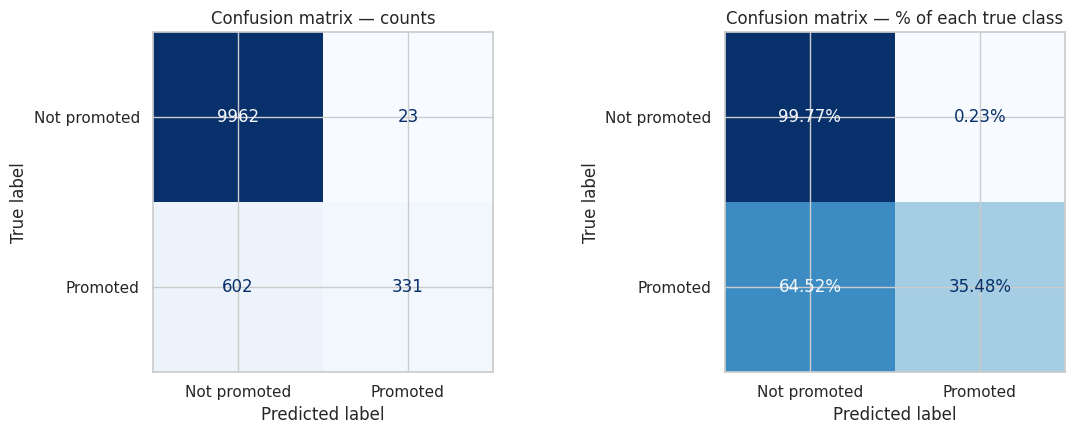

True promotions found (TP)   : 331
Promotions missed (FN)       : 602
False alarms (FP)            : 23
Correct non-promotions (TN)  : 9962


In [28]:
# ---- 3.11 Confusion matrix (counts and row-normalised) ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix — counts")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"),
                       display_labels=["Not promoted", "Promoted"]).plot(ax=axes[1], cmap="Blues",
                                                                         values_format=".2%", colorbar=False)
axes[1].set_title("Confusion matrix — % of each true class")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"True promotions found (TP)   : {tp}")
print(f"Promotions missed (FN)       : {fn}")
print(f"False alarms (FP)            : {fp}")
print(f"Correct non-promotions (TN)  : {tn}")

**📝 What this shows:** It finds 331 promotions with few false alarms, and its rules can be read and explained to HR.

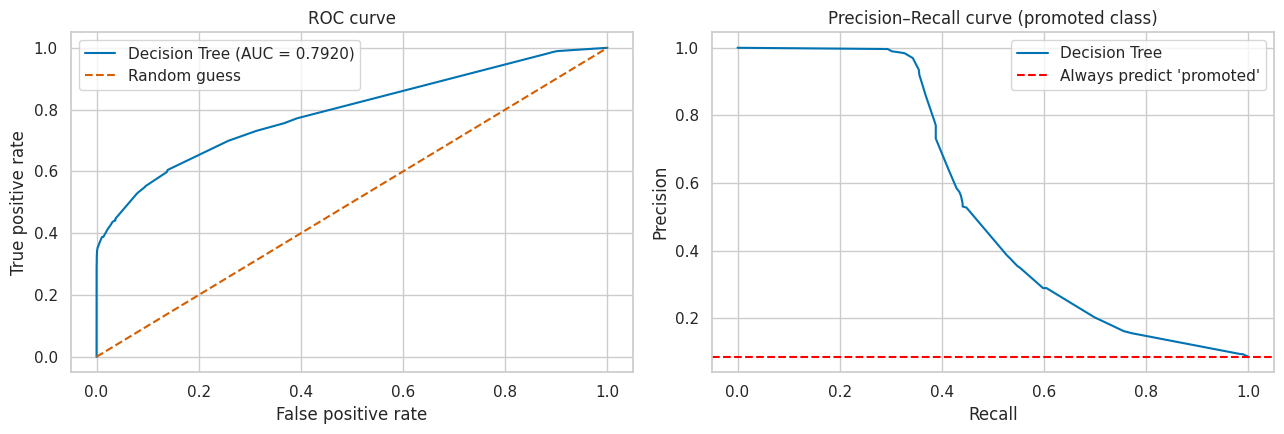

In [29]:
# ---- 3.12 ROC and Precision-Recall curves ----
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(fpr, tpr, label=f"Decision Tree (AUC = {tuned_scores['ROC_AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], "r--", label="Random guess")
axes[0].set_title("ROC curve"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].legend()

axes[1].plot(rec, prec, label="Decision Tree")
axes[1].axhline(y_test.mean(), color="red", linestyle="--", label="Always predict 'promoted'")
axes[1].set_title("Precision–Recall curve (promoted class)")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()

**📝 What this shows:** The ROC curve looks like steps because a tree with 34 leaves can only give 34 different probability values.

In [30]:
# ---- 3.13 5-fold stratified cross-validation ----
cv_scores = cross_val_score(dt_best, X_train_p, y_train, cv=skf, scoring="f1")
acc_scores = cross_val_score(dt_best, X_train_p, y_train, cv=skf, scoring="accuracy")
print("CV F1 (promoted) per fold:", np.round(cv_scores, 4))
print(f"Mean CV F1: {cv_scores.mean():.4f}  (± {cv_scores.std():.4f})")
print("Mean CV accuracy: %.4f" % acc_scores.mean())

CV F1 (promoted) per fold: [0.4897 0.502  0.5078 0.5248 0.4915]
Mean CV F1: 0.5032  (± 0.0127)
Mean CV accuracy: 0.9418


In [31]:
# ---- 3.14 Save results for the Part-A comparison table ----
os.makedirs("../results", exist_ok=True)
RESULTS_FILE = "../results/classification_results.csv"
MODEL_NAME = "Decision Tree Classifier"

row = pd.DataFrame([{
    "Model": MODEL_NAME,
    **tuned_scores,
    "CV_F1_promoted": cv_scores.mean(),
    "Tuned": "Yes (GridSearchCV)",
    "Best_params": str(best_params),
}])
if os.path.exists(RESULTS_FILE):
    old = pd.read_csv(RESULTS_FILE)
    row = pd.concat([old[old["Model"] != MODEL_NAME], row], ignore_index=True)
row.to_csv(RESULTS_FILE, index=False)
row.round(4)

,Model,Accuracy,F1_weighted,Precision_weighted,Recall_weighted,F1_promoted,Recall_promoted,ROC_AUC,CV_F1_promoted,Tuned,Best_params
0,Support Vector Machine (SVC),0.9416,0.9289,0.9409,0.9416,0.5000,0.3419,0.7517,0.4794,Yes (GridSearchCV),"{'C': 10, 'class_weight': None, 'gamma': 'scal..."
1,Logistic Regression,0.9395,0.9249,0.9407,0.9395,0.4634,0.3055,0.7897,0.4494,Yes (GridSearchCV),"{'C': 1, 'class_weight': None, 'penalty': 'l2'..."
2,Naive Bayes (Gaussian),0.9349,0.9264,0.9261,0.9349,0.5120,0.3998,0.7822,0.4861,Yes (GridSearchCV),{'var_smoothing': 0.1}
3,Decision Tree Classifier,0.9428,0.9307,0.9423,0.9428,0.5144,0.3548,0.7920,0.5032,Yes (GridSearchCV),"{'class_weight': None, 'criterion': 'gini', 'm..."


## Summary

**📝 In short:** The Decision Tree is the best Part A model (F1 0.931), and its three simple rules can be explained to anyone.